# Food Price Inflation Tracker - Data Loading & Exploration

## Objective
This notebook loads all converted datasets and performs initial exploratory analysis to understand:
- Data structure and quality
- Time ranges and coverage
- Key commodities and markets
- Trends and patterns

## Datasets
1. **WFP Food Prices (Kenya)** - Comprehensive food price data 2006-2021
2. **Housing Data (Converted)** - Existing housing datasets (for comparison)
3. **Sample Kenya Food Prices** - Generated sample data with trends

In [12]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


loading the other kenyan data

In [13]:
# Load each dataset 
household = pd.read_csv("../data/processed/Household_Information_Data.csv")
individual = pd.read_csv("../data/processed/Individual_Data.csv")
dwelling = pd.read_csv("../data/processed/Dwelling_Units_Data.csv")
county = pd.read_csv("../data/processed/County_Physical_Planning_Data.csv")
institution = pd.read_csv("../data/processed/KHS_Institutional_Data.csv")
land = pd.read_csv("../data/processed/Land_Parcels_Data.csv")
nema = pd.read_csv("../data/processed/NEMA_Data_Set.csv")
financiers = pd.read_csv("../data/processed/Housing_Financiers_Data.csv")
loans = pd.read_csv("../data/processed/Housing_Loans_Data.csv")
mortgage = pd.read_csv("../data/processed/Housing_Mortgage_Data.csv")
project = pd.read_csv("../data/processed/Project Information.csv")

# Quick summary
print(f"1. Household: {household.shape[0]:,} rows × {household.shape[1]} cols")
print(f"2. Individual: {individual.shape[0]:,} rows × {individual.shape[1]} cols")
print(f"3. Dwelling: {dwelling.shape[0]:,} rows × {dwelling.shape[1]} cols")
print(f"4. County: {county.shape[0]:,} rows × {county.shape[1]} cols")
print(f"5. Institution: {institution.shape[0]:,} rows × {institution.shape[1]} cols")
print(f"6. Land: {land.shape[0]:,} rows × {land.shape[1]} cols")
print(f"7. NEMA: {nema.shape[0]:,} rows × {nema.shape[1]} cols")
print(f"8. Financiers: {financiers.shape[0]:,} rows × {financiers.shape[1]} cols")
print(f"9. Loans: {loans.shape[0]:,} rows × {loans.shape[1]} cols")
print(f"10. Mortgage: {mortgage.shape[0]:,} rows × {mortgage.shape[1]} cols")
print(f"11. Project: {project.shape[0]:,} rows × {project.shape[1]} cols")

1. Household: 21,347 rows × 392 cols
2. Individual: 80,889 rows × 97 cols
3. Dwelling: 25,116 rows × 25 cols
4. County: 47 rows × 116 cols
5. Institution: 348 rows × 194 cols
6. Land: 11,136 rows × 34 cols
7. NEMA: 48 rows × 45 cols
8. Financiers: 351 rows × 63 cols
9. Loans: 946 rows × 10 cols
10. Mortgage: 1,644 rows × 13 cols
11. Project: 71 rows × 211 cols


In [22]:
# head of each dataset
print("📊 FIRST 3 ROWS OF EACH DATASET")
print(" " * 80)

# List of datasets with names
datasets = [
    ("Household", household),
    ("Individual", individual),
    ("Dwelling", dwelling),
    ("County", county),
    ("Institution", institution),
    ("Land", land),
    ("NEMA", nema),
    ("Financiers", financiers),
    ("Loans", loans),
    ("Mortgage", mortgage),
    ("Project", project)
]

# Show head of each
for name, df in datasets:
    print(f"\n{' '*60}")
    print(f"🏠 {name.upper()} DATASET - First 3 rows")
    print(f"{' '*60}")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nFirst 3 rows (first 10 columns):")
    print(df.iloc[:3, :10])  # First 3 rows, first 10 columns
    print("\n" + "="*60)

📊 FIRST 3 ROWS OF EACH DATASET
                                                                                

                                                            
🏠 HOUSEHOLD DATASET - First 3 rows
                                                            
Shape: 21347 rows × 392 columns

First 3 rows (first 10 columns):
  interview__key                     interview__id       a01  countycode  \
0    00-00-55-14  8a585d4dd71641b8a1348be6cc11e121  Laikipia          31   
1    00-01-22-52  d155c88b64de40148cda8dd079c36baa      Embu          14   
2    00-02-11-67  b511ae4612704d9b9d395c901d975644    Vihiga          38   

   a07_1    serial  a12                          c01_1 c01_1other  \
0  Urban  35312800    6         PUBLIC WATER COMPANIES        NaN   
1  Urban  44136136    3         PUBLIC WATER COMPANIES        NaN   
2  Urban  99694240    7  WATER FROM SPRING (Protected)        NaN   

                  c01_2  
0    PIPED TO YARD/PLOT  
1   PIPED INTO DWELLING  
2  F

In [23]:
# checking all column names for Household (most important)
print("🏠 HOUSEHOLD DATASET - ALL COLUMNS")
print("=" * 80)
for i, col in enumerate(household.columns):
    print(f"{i+1:3}. {col}")

print(f"\nTotal columns: {len(household.columns)}")

# Show first 5 rows with ALL columns transposed for better view
print("\n📋 FIRST 5 ROWS (transposed to see all columns):")
print(household.head(5).T)

🏠 HOUSEHOLD DATASET - ALL COLUMNS
  1. interview__key
  2. interview__id
  3. a01
  4. countycode
  5. a07_1
  6. serial
  7. a12
  8. c01_1
  9. c01_1other
 10. c01_2
 11. c01_2other
 12. c01_3
 13. c01_4
 14. c01_5
 15. c02_1
 16. c02_1other
 17. c02_2
 18. c02_2other
 19. c02_3
 20. c02_4
 21. c02_5
 22. c03
 23. c03_other
 24. c04
 25. c04other
 26. c05
 27. c06
 28. c07
 29. c07_1
 30. c08
 31. c09__1
 32. c09__2
 33. c09__3
 34. c09__4
 35. c09__5
 36. c09__6
 37. c09__7
 38. c09__96
 39. c09_other
 40. c10
 41. c10_1
 42. c10_2
 43. c10_3
 44. c10_4
 45. c11
 46. c11_other
 47. c11_1
 48. c11_2
 49. c11_2_1
 50. c11_3
 51. c11_4__1
 52. c11_4__2
 53. c11_4__3
 54. c11_4__4
 55. c11_4__5
 56. c11_4__6
 57. c11_4__7
 58. c11_4__98
 59. c12
 60. c12_other
 61. c12_1
 62. c12_1_1
 63. c12_2
 64. c12_3
 65. c12_3_1
 66. c12_4
 67. c13__1
 68. c13__2
 69. c13__3
 70. c13__4
 71. c13__5
 72. c13__6
 73. c13__7
 74. c13__96
 75. c13_other
 76. c14_1
 77. c14_2
 78. c14_3
 79. d01
 80. d

## 1. Load WFP Kenya Food Prices Dataset

In [14]:
# Load WFP Kenya food prices
wfp_kenya = pd.read_csv('../data/raw/wfp_food_prices_kenya_full.csv')

print("WFP KENYA FOOD PRICES DATASET")

print(f"\nShape: {wfp_kenya.shape}")
print(f"Date Range: {wfp_kenya['mp_year'].min()}-{wfp_kenya['mp_month'].min():02.0f} to {wfp_kenya['mp_year'].max()}-{wfp_kenya['mp_month'].max():02.0f}")
print(f"Commodities: {wfp_kenya['cm_name'].nunique()}")
print(f"Markets: {wfp_kenya['mkt_name'].nunique()}")
print(f"Regions: {wfp_kenya['adm1_name'].nunique()}")
print(f"\nColumns: {list(wfp_kenya.columns)}")
print(f"\nFirst few rows:")
wfp_kenya.head()

WFP KENYA FOOD PRICES DATASET

Shape: (8884, 18)
Date Range: 2006-01 to 2021-12
Commodities: 34
Markets: 45
Regions: 6

Columns: ['adm0_id', 'adm0_name', 'adm1_id', 'adm1_name', 'mkt_id', 'mkt_name', 'cm_id', 'cm_name', 'cur_id', 'cur_name', 'pt_id', 'pt_name', 'um_id', 'um_name', 'mp_month', 'mp_year', 'mp_price', 'mp_commoditysource']

First few rows:


,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource
0,133.0,Kenya,51326,Coast,191,Mombasa,50,Beans - Wholesale,0.0,KES,14,Wholesale,5,KG,1,2006,33.630,NaN
1,133.0,Kenya,51326,Coast,191,Mombasa,50,Beans - Wholesale,0.0,KES,14,Wholesale,5,KG,2,2006,39.478,NaN
2,133.0,Kenya,51326,Coast,191,Mombasa,50,Beans - Wholesale,0.0,KES,14,Wholesale,5,KG,3,2006,44.686,NaN
3,133.0,Kenya,51326,Coast,191,Mombasa,50,Beans - Wholesale,0.0,KES,14,Wholesale,5,KG,4,2006,43.837,NaN
4,133.0,Kenya,51326,Coast,191,Mombasa,50,Beans - Wholesale,0.0,KES,14,Wholesale,5,KG,5,2006,39.734,NaN


In [15]:
# Data types and missing values
print("DATA QUALITY CHECK")
print("="*80)
print("\nData Types:")
print(wfp_kenya.dtypes)
print("\nMissing Values:")
missing = wfp_kenya.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
else:
    print("No missing values!")

print("\nBasic Statistics:")
wfp_kenya.describe()

DATA QUALITY CHECK

Data Types:
adm0_id               float64
adm0_name              object
adm1_id                 int64
adm1_name              object
mkt_id                  int64
mkt_name               object
cm_id                   int64
cm_name                object
cur_id                float64
cur_name               object
pt_id                   int64
pt_name                object
um_id                   int64
um_name                object
mp_month                int64
mp_year                 int64
mp_price              float64
mp_commoditysource    float64
dtype: object

Missing Values:
mp_commoditysource    8884
dtype: int64

Basic Statistics:


,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price,mp_commoditysource
count,8884.0,8884.000000,8884.000000,8884.000000,8884.0,8884.000000,8884.000000,8884.000000,8884.000000,8884.000000,0.0
mean,133.0,51328.941693,1290.236830,148.785682,0.0,14.500675,12.835660,5.941805,2015.393291,1191.952042,NaN
std,0.0,1.793449,1551.480288,153.004957,0.0,0.500028,10.586515,3.266864,4.907266,1958.167722,NaN
min,133.0,51326.000000,184.000000,50.000000,0.0,14.000000,5.000000,1.000000,2006.000000,5.000000,NaN
25%,133.0,51328.000000,185.000000,65.000000,0.0,14.000000,5.000000,3.000000,2011.000000,46.410250,NaN
50%,133.0,51329.000000,188.000000,67.000000,0.0,15.000000,5.000000,6.000000,2016.000000,84.060000,NaN
75%,133.0,51331.000000,3244.000000,254.000000,0.0,15.000000,17.000000,8.000000,2021.000000,1916.352000,NaN
max,133.0,51331.000000,4629.000000,817.000000,0.0,15.000000,115.000000,12.000000,2021.000000,10350.000000,NaN


## 2. Top Commodities Analysis

TOP 15 COMMODITIES BY DATA POINTS
cm_name
Maize (white) - Retail              1052
Maize - Wholesale                    832
Beans (dry) - Wholesale              733
Maize (white) - Wholesale            733
Beans - Wholesale                    724
Sorghum - Wholesale                  708
Potatoes (Irish) - Wholesale         706
Beans (dry) - Retail                 556
Oil (vegetable) - Retail             341
Milk (cow, pasteurized) - Retail     178
Bread - Retail                       178
Rice - Retail                        165
Sugar - Retail                       165
Salt - Retail                        164
Maize flour - Retail                 164
Name: count, dtype: int64


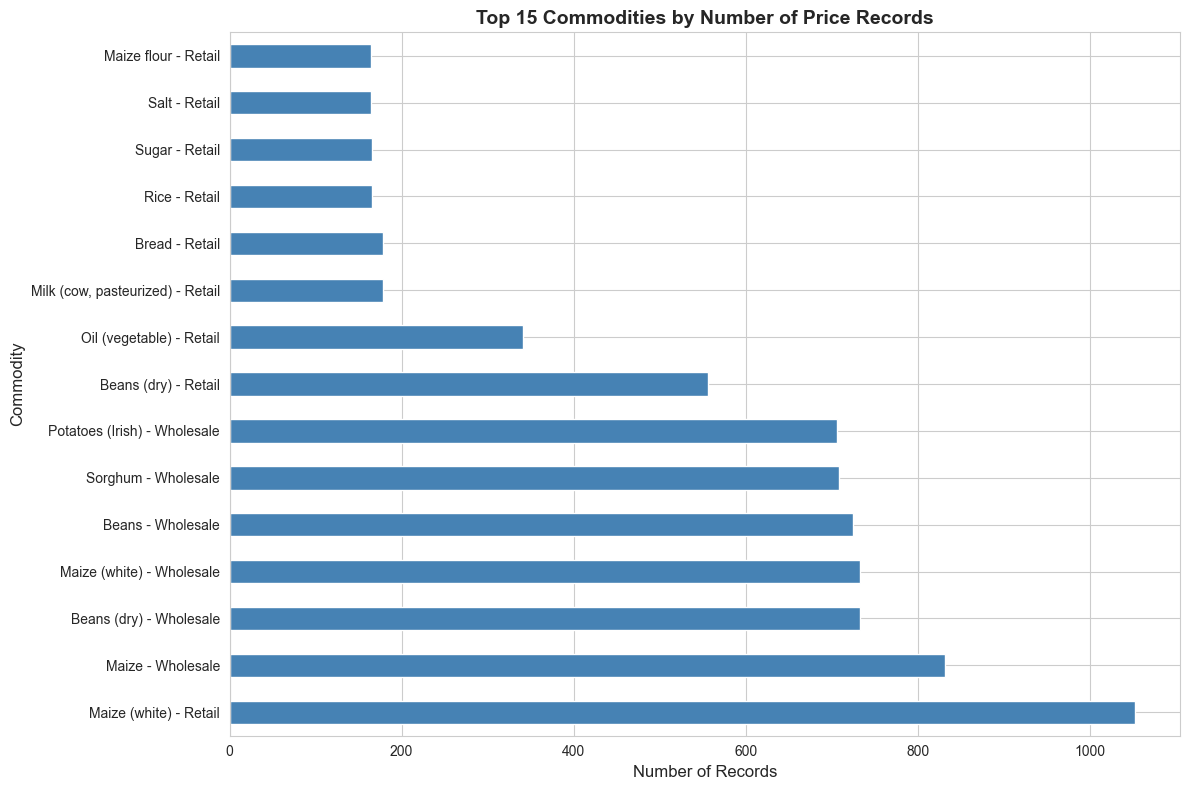



ALL 34 COMMODITIES:
1. Bananas - Retail
2. Beans (dry) - Retail
3. Beans (dry) - Wholesale
4. Beans - Wholesale
5. Bread - Retail
6. Cabbage - Retail
7. Cooking fat - Retail
8. Fuel (diesel) - Retail
9. Fuel (kerosene) - Retail
10. Fuel (petrol-gasoline) - Retail
11. Kale - Retail
12. Maize (white) - Retail
13. Maize (white) - Wholesale
14. Maize - Retail
15. Maize - Wholesale
16. Maize flour - Retail
17. Meat (beef) - Retail
18. Meat (camel) - Retail
19. Meat (goat) - Retail
20. Milk (UHT) - Retail
21. Milk (camel, fresh) - Retail
22. Milk (cow, fresh) - Retail
23. Milk (cow, pasteurized) - Retail
24. Oil (vegetable) - Retail
25. Onions (red) - Retail
26. Potatoes (Irish) - Retail
27. Potatoes (Irish) - Wholesale
28. Rice - Retail
29. Salt - Retail
30. Sorghum - Retail
31. Sorghum - Wholesale
32. Sugar - Retail
33. Tomatoes - Retail
34. Wheat flour - Retail


In [16]:
# Commodity distribution
print("TOP 15 COMMODITIES BY DATA POINTS")
print("="*80)
commodity_counts = wfp_kenya['cm_name'].value_counts().head(15)
print(commodity_counts)

# Visualize
plt.figure(figsize=(12, 8))
commodity_counts.plot(kind='barh', color='steelblue')
plt.title('Top 15 Commodities by Number of Price Records', fontsize=14, fontweight='bold')
plt.xlabel('Number of Records', fontsize=12)
plt.ylabel('Commodity', fontsize=12)
plt.tight_layout()
plt.show()

# All unique commodities
print(f"\n\nALL {wfp_kenya['cm_name'].nunique()} COMMODITIES:")
print("="*80)
for i, commodity in enumerate(sorted(wfp_kenya['cm_name'].unique()), 1):
    print(f"{i}. {commodity}")

## 3. Markets and Regional Analysis

TOP 15 MARKETS BY DATA POINTS
mkt_name
Nairobi                 1748
Eldoret town            1011
Kisumu                   974
Kitui                    647
Mombasa                  632
Nakuru                   535
Mandera                  179
Lodwar (Turkana)         177
Marsabit                 171
Kilifi                   142
Kajiado                  140
Marigat (Baringo)        139
Mukuru (Nairobi)         107
Kakuma 3                 103
Kawangware (Nairobi)     103
Name: count, dtype: int64


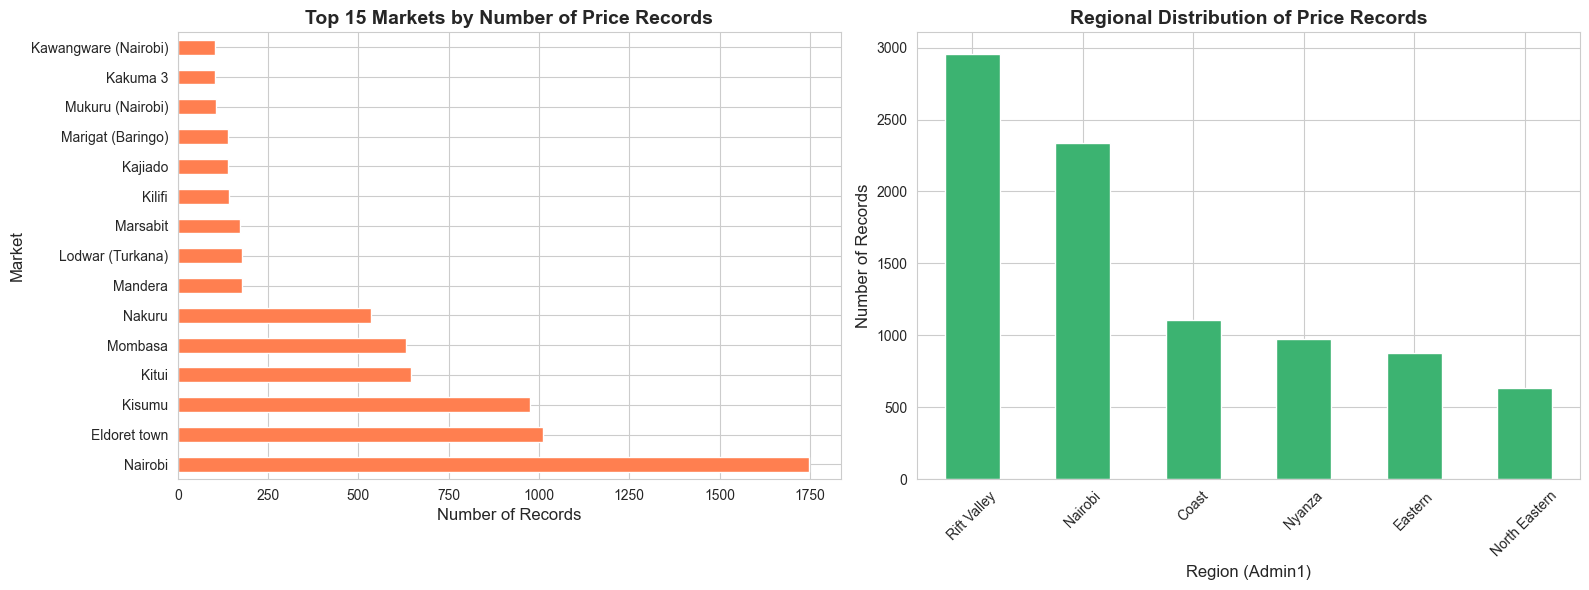


REGIONAL COVERAGE:
adm1_name
Rift Valley      2958
Nairobi          2335
Coast            1105
Nyanza            974
Eastern           879
North Eastern     633
Name: count, dtype: int64


In [17]:
# Market distribution
print("TOP 15 MARKETS BY DATA POINTS")
print("="*80)
market_counts = wfp_kenya['mkt_name'].value_counts().head(15)
print(market_counts)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Markets
market_counts.plot(kind='barh', ax=ax1, color='coral')
ax1.set_title('Top 15 Markets by Number of Price Records', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Records', fontsize=12)
ax1.set_ylabel('Market', fontsize=12)

# Regions
region_counts = wfp_kenya['adm1_name'].value_counts()
region_counts.plot(kind='bar', ax=ax2, color='mediumseagreen')
ax2.set_title('Regional Distribution of Price Records', fontsize=14, fontweight='bold')
ax2.set_xlabel('Region (Admin1)', fontsize=12)
ax2.set_ylabel('Number of Records', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nREGIONAL COVERAGE:")
print(region_counts)

## 4. Price Analysis - Key Staple Foods

In [18]:
# Focus on key staple foods
staple_foods = [
    'Maize (white) - Retail',
    'Maize - Wholesale',
    'Beans (dry) - Retail',
    'Rice - Retail',
    'Oil (vegetable) - Retail',
    'Milk (cow, pasteurized) - Retail'
]

# Filter for staple foods
staples_df = wfp_kenya[wfp_kenya['cm_name'].isin(staple_foods)].copy()

print(f"STAPLE FOODS DATA")
print("="*80)
print(f"Total records for staple foods: {len(staples_df):,}")
print(f"\nBreakdown by commodity:")
print(staples_df['cm_name'].value_counts())

# Price statistics
print(f"\n\nPRICE STATISTICS BY COMMODITY")
print("="*80)
price_stats = staples_df.groupby('cm_name')['mp_price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print(price_stats)

STAPLE FOODS DATA
Total records for staple foods: 3,124

Breakdown by commodity:
cm_name
Maize (white) - Retail              1052
Maize - Wholesale                    832
Beans (dry) - Retail                 556
Oil (vegetable) - Retail             341
Milk (cow, pasteurized) - Retail     178
Rice - Retail                        165
Name: count, dtype: int64


PRICE STATISTICS BY COMMODITY
                                    mean  median    std     min     max
cm_name                                                                
Beans (dry) - Retail               92.71   96.00  21.40   23.00  175.00
Maize (white) - Retail             48.53   46.85  17.27    6.00  100.00
Maize - Wholesale                  28.10   29.06   8.89   10.43   60.02
Milk (cow, pasteurized) - Retail   37.18   43.00  10.34   20.00   57.00
Oil (vegetable) - Retail          192.80  198.18  32.07  100.00  250.00
Rice - Retail                      98.87  100.00  10.79   73.33  150.00


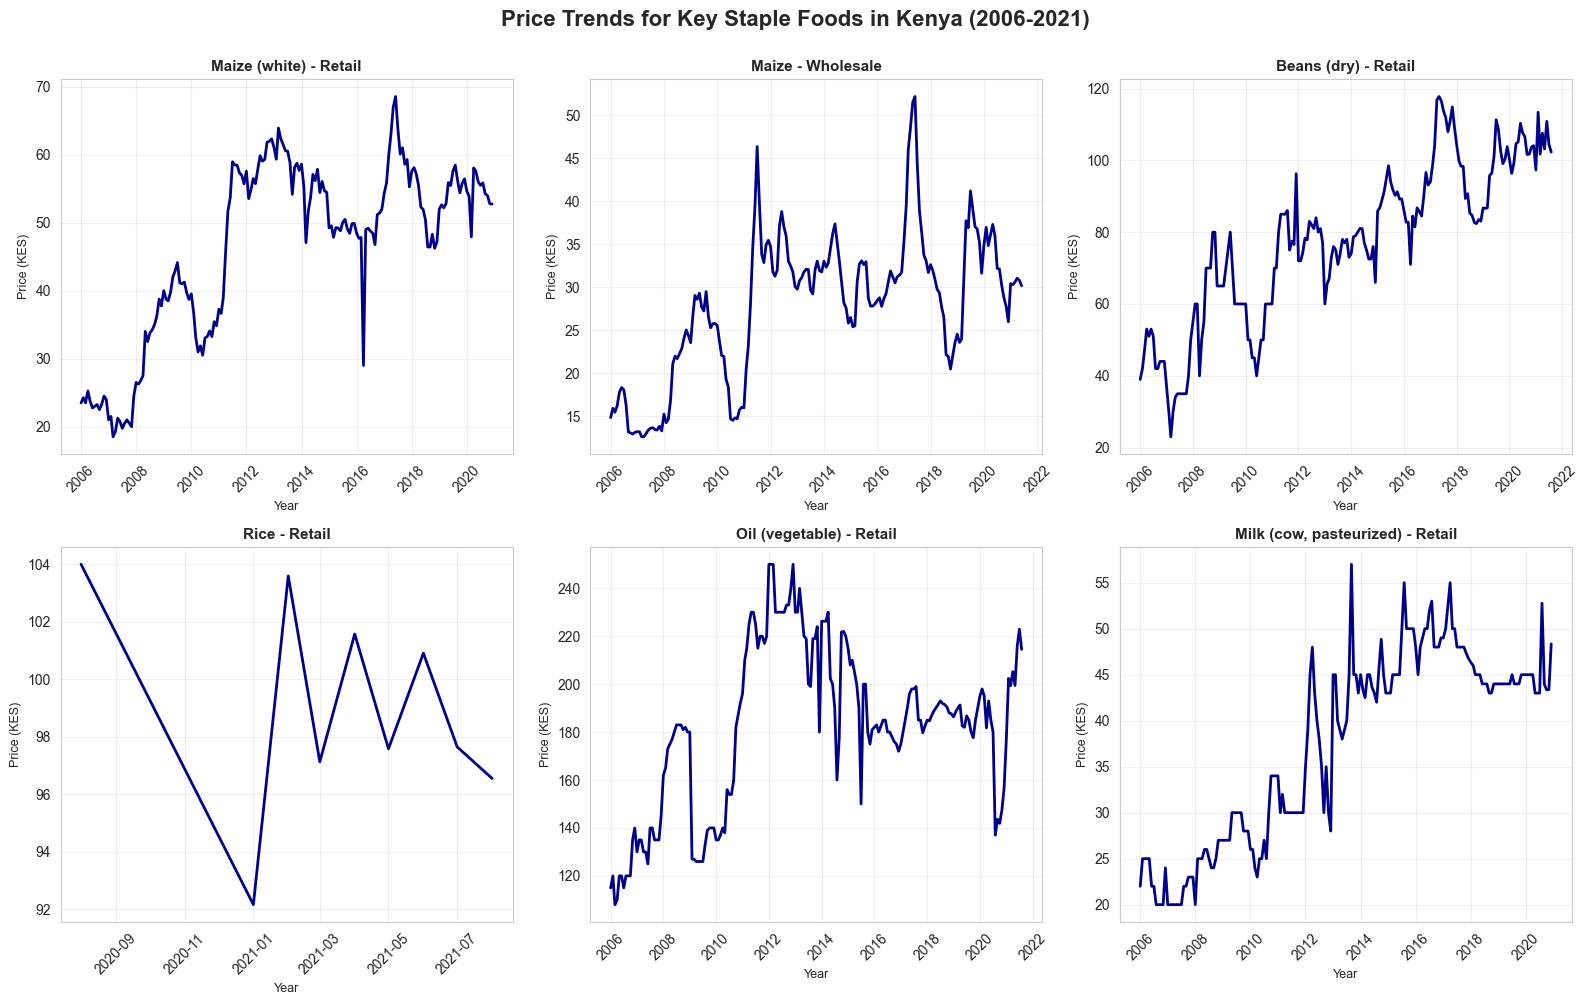


✓ Price trends plotted successfully!


In [19]:
# Create date column for time series analysis
staples_df['date'] = pd.to_datetime(
    staples_df['mp_year'].astype(int).astype(str) + '-' + 
    staples_df['mp_month'].astype(int).astype(str).str.zfill(2) + '-01'
)

# Average prices over time
price_trends = staples_df.groupby(['date', 'cm_name'])['mp_price'].mean().reset_index()

# Plot price trends
plt.figure(figsize=(16, 10))

for i, commodity in enumerate(staple_foods, 1):
    plt.subplot(2, 3, i)
    data = price_trends[price_trends['cm_name'] == commodity]
    if len(data) > 0:
        plt.plot(data['date'], data['mp_price'], linewidth=2, color='darkblue')
        plt.title(commodity, fontsize=11, fontweight='bold')
        plt.xlabel('Year', fontsize=9)
        plt.ylabel('Price (KES)', fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

plt.suptitle('Price Trends for Key Staple Foods in Kenya (2006-2021)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ Price trends plotted successfully!")

## 5. Inflation Analysis - Year-over-Year Changes

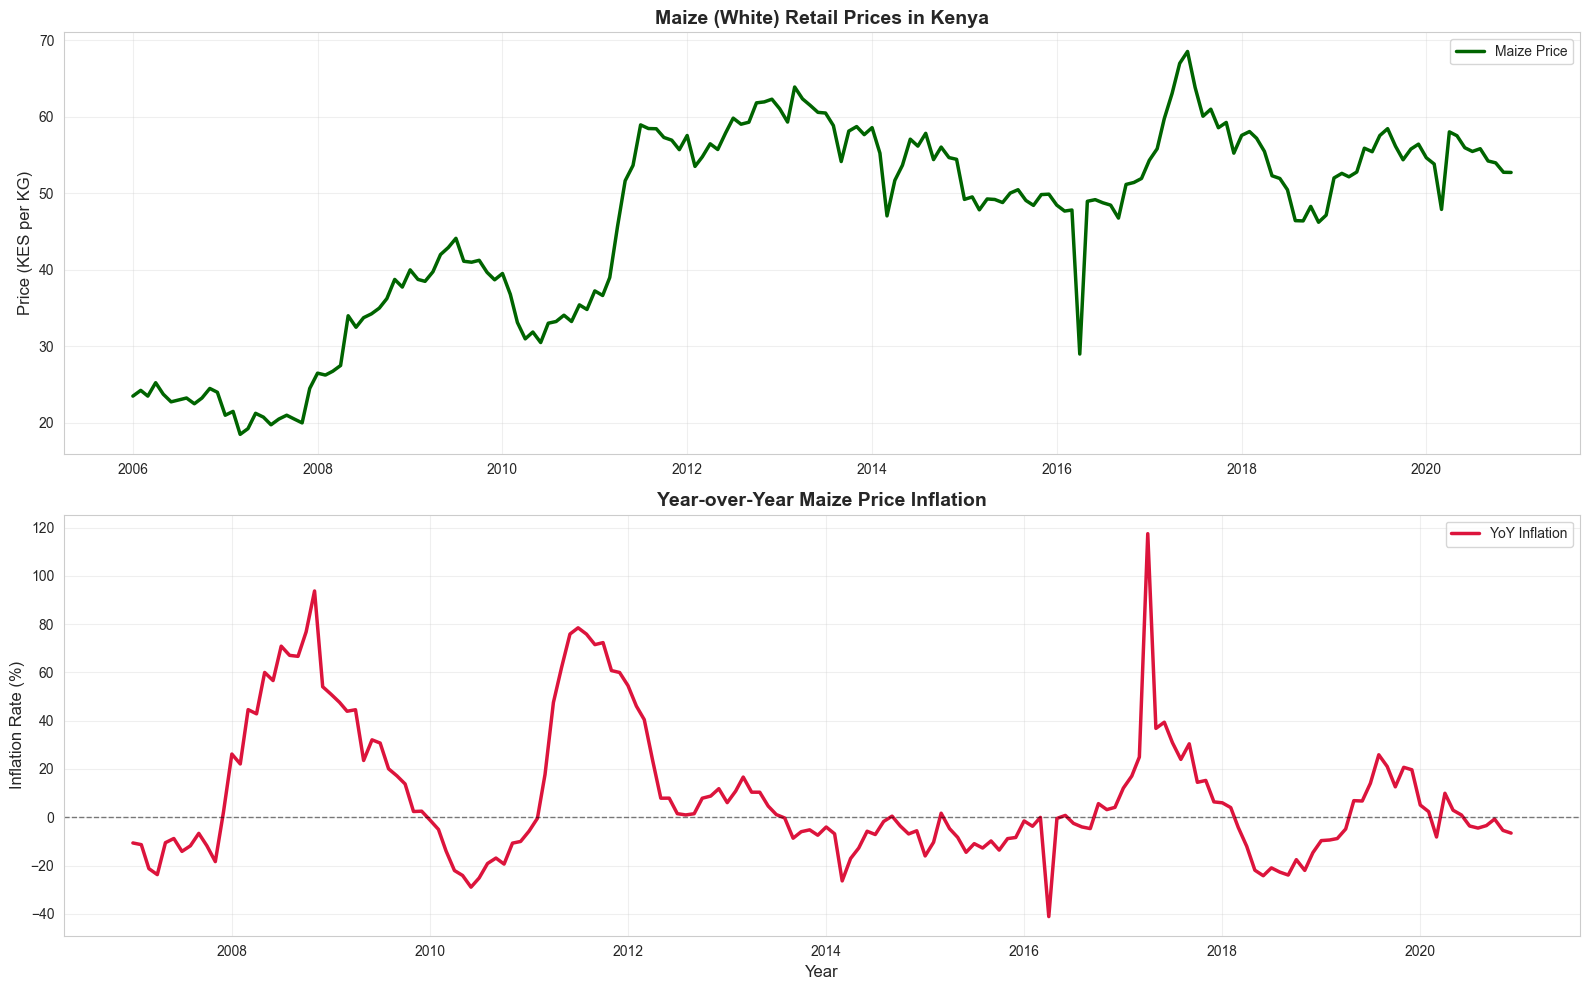


MAIZE INFLATION STATISTICS
Average YoY Inflation: 9.22%
Highest Inflation: 117.47% (2017-04)
Lowest Inflation: -41.14% (2016-04)


In [20]:
# Calculate year-over-year inflation for Maize (most important staple)
maize_retail = wfp_kenya[wfp_kenya['cm_name'] == 'Maize (white) - Retail'].copy()
maize_retail['date'] = pd.to_datetime(
    maize_retail['mp_year'].astype(int).astype(str) + '-' + 
    maize_retail['mp_month'].astype(int).astype(str).str.zfill(2) + '-01'
)

# Monthly average prices
maize_monthly = maize_retail.groupby('date')['mp_price'].mean().reset_index()
maize_monthly = maize_monthly.sort_values('date')

# Calculate YoY inflation
maize_monthly['price_12m_ago'] = maize_monthly['mp_price'].shift(12)
maize_monthly['yoy_inflation'] = ((maize_monthly['mp_price'] - maize_monthly['price_12m_ago']) / maize_monthly['price_12m_ago'] * 100)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Prices
ax1.plot(maize_monthly['date'], maize_monthly['mp_price'], linewidth=2.5, color='darkgreen', label='Maize Price')
ax1.set_title('Maize (White) Retail Prices in Kenya', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (KES per KG)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Inflation
ax2.plot(maize_monthly['date'], maize_monthly['yoy_inflation'], linewidth=2.5, color='crimson', label='YoY Inflation')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('Year-over-Year Maize Price Inflation', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Inflation Rate (%)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("\nMAIZE INFLATION STATISTICS")
print("="*80)
print(f"Average YoY Inflation: {maize_monthly['yoy_inflation'].mean():.2f}%")
print(f"Highest Inflation: {maize_monthly['yoy_inflation'].max():.2f}% ({maize_monthly.loc[maize_monthly['yoy_inflation'].idxmax(), 'date'].strftime('%Y-%m')})")
print(f"Lowest Inflation: {maize_monthly['yoy_inflation'].min():.2f}% ({maize_monthly.loc[maize_monthly['yoy_inflation'].idxmin(), 'date'].strftime('%Y-%m')})")

## 6. Sample Data Exploration

In [21]:
# Load sample data
sample_data = pd.read_csv('../data/raw/kenya_food_prices_sample.csv')

print("SAMPLE KENYA FOOD PRICES DATASET")
print("="*80)
print(f"Shape: {sample_data.shape}")
print(f"Date Range: {sample_data['date'].min()} to {sample_data['date'].max()}")
print(f"Commodities: {sample_data['commodity'].nunique()}")
print(f"Markets: {sample_data['market'].nunique()}")

print("\nCommodities in sample:")
print(sample_data['commodity'].unique())

print("\nMarkets in sample:")
print(sample_data['market'].unique())

sample_data.head(10)

SAMPLE KENYA FOOD PRICES DATASET
Shape: (2400, 8)
Date Range: 2020-01-01 to 2024-12-01
Commodities: 8
Markets: 5

Commodities in sample:
['Maize (white)' 'Rice' 'Wheat flour' 'Beans (dry)' 'Sugar'
 'Cooking oil (vegetable)' 'Milk (fresh)' 'Eggs']

Markets in sample:
['Nairobi' 'Mombasa' 'Kisumu' 'Nakuru' 'Eldoret']


,date,admin1,market,commodity,unit,price,currency,source
0,2020-01-01,Kenya,Nairobi,Maize (white),KG,49.57,KES,Sample Data
1,2020-01-01,Kenya,Mombasa,Maize (white),KG,48.01,KES,Sample Data
2,2020-01-01,Kenya,Kisumu,Maize (white),KG,46.05,KES,Sample Data
3,2020-01-01,Kenya,Nakuru,Maize (white),KG,49.14,KES,Sample Data
4,2020-01-01,Kenya,Eldoret,Maize (white),KG,48.50,KES,Sample Data
5,2020-01-01,Kenya,Nairobi,Rice,KG,132.20,KES,Sample Data
6,2020-01-01,Kenya,Mombasa,Rice,KG,123.21,KES,Sample Data
7,2020-01-01,Kenya,Kisumu,Rice,KG,123.10,KES,Sample Data
8,2020-01-01,Kenya,Nakuru,Rice,KG,127.09,KES,Sample Data
9,2020-01-01,Kenya,Eldoret,Rice,KG,124.30,KES,Sample Data
